# Phase 4 — Simulated checkpoint inhibitor

Pick a point clearly in the **escape** phase (ρ_I = 300, α = 10). Run two simulations from the
same seed:

* **No treatment** — α stays at 10.0 for the whole run. Tumor saturates.
* **With treatment** — at `t = 20`, set α to 0 (full checkpoint inhibition). Same seed,
  same initial condition, identical noise stream up to that moment.

If the model captures the biology, the second trajectory should pivot from escape to clearance.

In [1]:
import sys, pathlib
# robust root resolution: walk up until we find src/
ROOT = pathlib.Path().resolve()
while not (ROOT / 'src').is_dir() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from src import style
style.apply_style()

# load cached treatment trajectories
d = np.load(ROOT / 'outputs' / 'data' / 'treatment_runs.npz', allow_pickle=True)
print('cached fields:', sorted(d.files))
rho_I = int(d['rho_I']); alpha = float(d['alpha']); alpha_after = float(d['alpha_after']); t_treat = float(d['t_treat'])
print(f'ρ_I = {rho_I}   α = {alpha} → {alpha_after} at t = {t_treat}')

cached fields: ['alpha', 'alpha_after', 'no_treat_nI', 'no_treat_nT', 'no_treat_times', 'rho_I', 't_treat', 'treat_nI', 'treat_nT', 'treat_times']
ρ_I = 300   α = 10.0 → 0.0 at t = 20.0


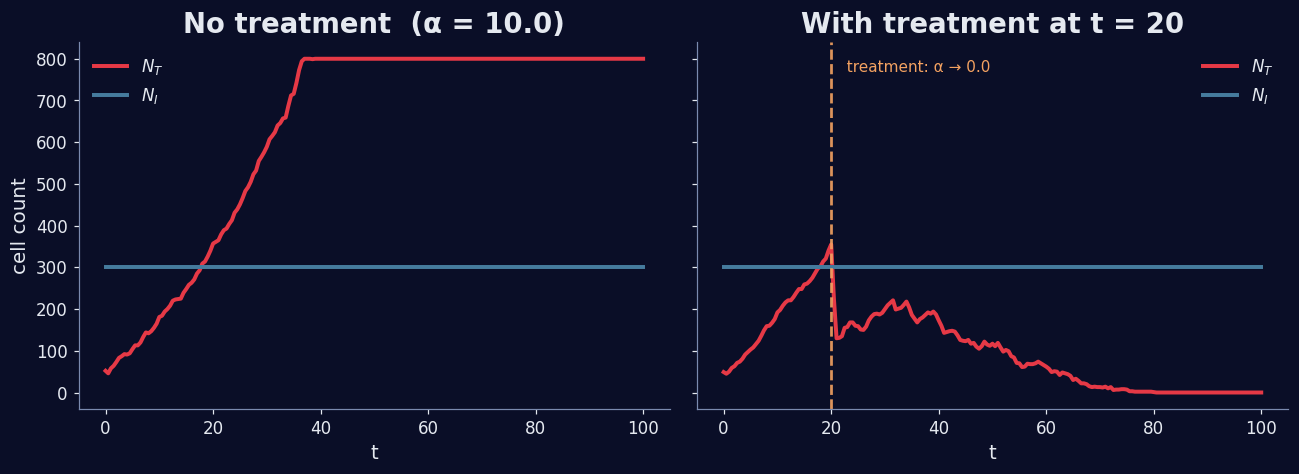

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=110, sharey=True)
fig.patch.set_facecolor(style.BG)
for ax in axes: ax.set_facecolor(style.BG)

ax = axes[0]
ax.plot(d['no_treat_times'], d['no_treat_nT'], color=style.TUMOR, lw=2.6, label=r'$N_T$')
ax.plot(d['no_treat_times'], d['no_treat_nI'], color=style.TCELL, lw=2.6, label=r'$N_I$')
ax.set_xlabel('t'); ax.set_ylabel('cell count')
ax.set_title(f'No treatment  (α = {alpha:.1f})', color=style.FG)
ax.legend(frameon=False)

ax = axes[1]
ax.plot(d['treat_times'], d['treat_nT'], color=style.TUMOR, lw=2.6, label=r'$N_T$')
ax.plot(d['treat_times'], d['treat_nI'], color=style.TCELL, lw=2.6, label=r'$N_I$')
ax.axvline(t_treat, color=style.ACCENT, lw=1.8, ls='--', alpha=0.9)
ax.text(t_treat + 1, ax.get_ylim()[1] * 0.95,
        f'  treatment: α → {alpha_after:.1f}',
        color=style.ACCENT, fontsize=10, verticalalignment='top')
ax.set_xlabel('t')
ax.set_title(f'With treatment at t = {t_treat:.0f}', color=style.FG)
ax.legend(frameon=False)
plt.tight_layout()

**Reading the figure.** Identical trajectory up to t = 20 (350 tumor cells, escape-phase
behavior). Then α drops to 0 and the orange dashed line marks the moment. T cells flood
into the tumor mass and the tumor curve plunges 350 → 130 in ~5 time units, then continues
to decline to extinction by t ≈ 90. **The same starting state goes to two opposite outcomes
depending on whether or not you flip a single parameter mid-run.**

Mechanistically, this is exactly what anti-PD-1 / anti-PD-L1 antibodies do clinically:
they reduce the effective immunosuppression around tumors, letting infiltrating CD8+ T
cells re-engage.

## 4.1  Watch the videos

Each phase has an MP4 in `outputs/videos/`. The treatment one is the most dramatic — you
see the moment T cells stop being repelled and start swarming.

In [3]:
from IPython.display import Video
Video(str(ROOT / 'outputs' / 'videos' / 'treatment.mp4'), embed=False, width=720)

Other videos to watch:

* `outputs/videos/clearance.mp4` — overwhelming T-cell infiltration (the 'hot tumor').
* `outputs/videos/control.mp4`   — tumor pinned in a T-cell ring (the 'immune-excluded' tumor).
* `outputs/videos/escape.mp4`    — tumor mass with T cells repelled to the periphery (the 'cold tumor').

## 4.2  Biological mapping

| Simulation phase | Clinical phenotype | Histology signature |
|---|---|---|
| Clearance (low α)         | 'Hot' tumor               | Infiltrating CD8+ T cells |
| Control / dormancy        | Immune-excluded tumor     | T cells in a ring around the core |
| Escape (high α)           | 'Cold' tumor              | Few intratumoral T cells |

Treatment ≈ checkpoint inhibitor: lower α, push the system across the boundary.